In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna
import warnings
import polars as pl
import gc
import lightgbm as lgb
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation
from scipy.stats import spearmanr
import joblib
import kaggle_evaluation.default_inference_server
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
train_df = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')
test_df =pd.read_csv('/kaggle/input/hull-tactical-market-prediction/test.csv')

In [3]:
train_df.head(5)

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,I9,M1,M10,M11,M12,M13,M14,M15,M16,M17,M18,M2,M3,M4,M5,M6,M7,M8,M9,P1,P10,P11,P12,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


In [4]:
def describe_dataset(df: pd.DataFrame):
    """
    Provides a comprehensive, structured overview of a DataFrame, including
    dimensions, memory usage, data types, and detailed descriptive statistics.

    Args:
        df (pd.DataFrame): The input DataFrame to describe.
    """
    
    display(Markdown("## 📋 Dataset Overview"))
    print("--- Basic Dimensions & Memory ---")
    
    # shape
    num_rows, num_cols = df.shape
    print(f"**Shape (Rows, Columns):** ({num_rows:,}, {num_cols:,})")
    
    # memory
    mem_usage = df.memory_usage(deep=True).sum()
    mem_gbs = mem_usage / (1024**2)
    print(f"**Total Memory Usage:** {mem_gbs:.2f} MB")
    
    print("\n--- Feature Data Types and Counts ---")
    
    # 2. data types
    dtype_counts = df.dtypes.astype(str).value_counts().reset_index()
    dtype_counts.columns = ['Data_Type', 'Count']
    print(dtype_counts.to_markdown(index=False))

    
    # stats
    display(Markdown("\n## 📊 Descriptive Statistics"))
    
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

    # numerical
    if numerical_cols:
        display(Markdown("### Numerical Features"))
        # Use transpose for better readability when many features exist
        num_desc = df[numerical_cols].describe().T
        # Add IQR for a more detailed statistical view
        num_desc['IQR'] = num_desc['75%'] - num_desc['25%']
        display(num_desc.style.format("{:,.2f}"))
        print(f"Found {len(numerical_cols)} numerical features.")

    # categorical
    if categorical_cols:
        display(Markdown("### Categorical / Object Features"))
        # Include top, frequency, and unique count
        cat_desc = df[categorical_cols].describe().T
        display(cat_desc.style.format({"unique": "{:,}", "freq": "{:,}"}))
        print(f"Found {len(categorical_cols)} categorical/object features.")

    # datetime
    if datetime_cols:
        display(Markdown("### Datetime Features"))
        dt_desc = df[datetime_cols].describe().T
        display(dt_desc)
        print(f"Found {len(datetime_cols)} datetime features.")


def missing_duplicates_analysis(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    print("--- 📊 Missing Data and Duplicates Analysis ---")
    # missing summary
    missing_counts = df.isnull().sum()
    missing_summary = pd.DataFrame({
        'Missing_Count': missing_counts,
        'Missing_Percent': 100 * missing_counts / len(df)
    })
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
    missing_summary = missing_summary.sort_values(by='Missing_Count', ascending=False)
    
    
    # check for duplicates
    num_duplicates = df.duplicated().sum()
    print(f"**Duplicate rows found:** {df.duplicated().sum()}")
    
    # visualisation
    if missing_summary.empty:
        print("✅ **No missing values found** in the dataset.")
        return pd.DataFrame()
    
    print(f"\n**Total features with missing values:** {len(missing_summary)}")
    
    # Select the top n features
    plot_data = missing_summary.head(top_n)
    
    plt.style.use('ggplot')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=plot_data.index,
        y='Missing_Count',
        data=plot_data,
        palette='viridis'
    )
    
    # Add percentage labels above the bars
    for i, count in enumerate(plot_data['Missing_Count']):
        percent = plot_data['Missing_Percent'].iloc[i]
        plt.text(
            x=i, 
            y=count + (df.shape[0] * 0.005),
            s=f'{percent:.1f}%',
            ha='center',
            fontsize=9
        )
    
    plt.title(f"Top {min(top_n, len(missing_summary))} Features by Missing Values Count (Total Rows: {len(df)})", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Feature Name", fontsize=12)
    plt.ylabel("Missing Count", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("\n**Missing Data Summary Table (Top 10):**")
    print(missing_summary.head(10).to_markdown(floatfmt=".2f"))
    return missing_summary


def detect_outliers(df, method='iqr', threshold=2.5, z_threshold=3.0, cols=None, summary=True):

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if method not in ['iqr', 'zscore']:
        raise ValueError("method must be 'iqr' or 'zscore'")

    outlier_flags = pd.DataFrame(False, index=df.index, columns=cols)

    for col in cols:
        series = df[col].dropna()

        if method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

        elif method == 'zscore':
            z_scores = np.abs(stats.zscore(series))
            outlier_flags[col] = z_scores > z_threshold

    if summary:
        summary_df = pd.DataFrame({
            'outlier_count': outlier_flags.sum(),
            'percent_outliers': 100 * outlier_flags.sum() / len(df)
        }).sort_values('percent_outliers', ascending=False)

        print("📊 Outlier Detection Summary:")
        print(summary_df.round(2))
        return outlier_flags, summary_df

    return outlier_flags

In [5]:
describe_dataset(train_df)

## 📋 Dataset Overview

--- Basic Dimensions & Memory ---
**Shape (Rows, Columns):** (9,021, 98)
**Total Memory Usage:** 6.74 MB

--- Feature Data Types and Counts ---
| Data_Type   |   Count |
|:------------|--------:|
| float64     |      88 |
| int64       |      10 |



## 📊 Descriptive Statistics

### Numerical Features

,count,mean,std,min,25%,50%,75%,max,IQR
date_id,"9,021.00","4,510.00","2,604.28",0.00,"2,255.00","4,510.00","6,765.00","9,020.00","4,510.00"
D1,"9,021.00",0.03,0.17,0.00,0.00,0.00,0.00,1.00,0.00
D2,"9,021.00",0.03,0.17,0.00,0.00,0.00,0.00,1.00,0.00
D3,"9,021.00",0.05,0.21,0.00,0.00,0.00,0.00,1.00,0.00
D4,"9,021.00",0.57,0.49,0.00,0.00,1.00,1.00,1.00,1.00
D5,"9,021.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00,0.00
D6,"9,021.00",-0.24,0.43,-1.00,0.00,0.00,0.00,0.00,0.00
D7,"9,021.00",0.05,0.21,0.00,0.00,0.00,0.00,1.00,0.00
D8,"9,021.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00,0.00
D9,"9,021.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00,0.00


Found 98 numerical features.


--- 📊 Missing Data and Duplicates Analysis ---
**Duplicate rows found:** 0

**Total features with missing values:** 85


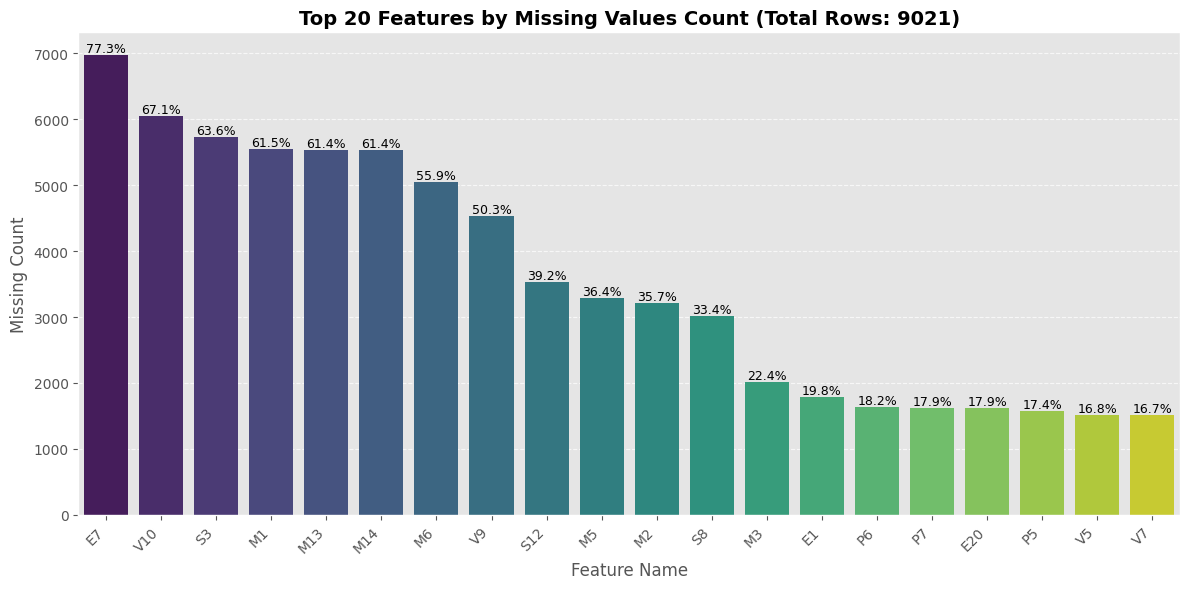


**Missing Data Summary Table (Top 10):**
|     |   Missing_Count |   Missing_Percent |
|:----|----------------:|------------------:|
| E7  |         6969.00 |             77.25 |
| V10 |         6049.00 |             67.05 |
| S3  |         5733.00 |             63.55 |
| M1  |         5547.00 |             61.49 |
| M13 |         5540.00 |             61.41 |
| M14 |         5540.00 |             61.41 |
| M6  |         5043.00 |             55.90 |
| V9  |         4539.00 |             50.32 |
| S12 |         3537.00 |             39.21 |
| M5  |         3283.00 |             36.39 |


In [6]:
missing_df_summary = missing_duplicates_analysis(train_df)

In [7]:
outliers, summary = detect_outliers(train_df, method='iqr')

📊 Outlier Detection Summary:
                               outlier_count  percent_outliers
D6                                      2148             23.81
D5                                      1718             19.04
E4                                      1396             15.48
D9                                      1290             14.30
D8                                      1287             14.27
E12                                     1129             12.52
E11                                     1032             11.44
E6                                       992             11.00
E14                                      632              7.01
P6                                       553              6.13
S5                                       498              5.52
D3                                       431              4.78
E13                                      414              4.59
D7                                       412              4.57
D2                        

### CONFIG

In [8]:
TRAIN_PATH = '/kaggle/input/hull-tactical-market-prediction/train.csv'
LOCAL_GATEWAY_PATH = '/kaggle/input/hull-tactical-market-prediction/'
MODEL_PATH = 'lgbm_model.cbm'
FEATURES_PATH = 'features.joblib'

TOP_FEATURES_FOR_FE = ['M4', 'V13', 'S5', 'S2', 'D2', 'E19', 'P7', 'P6', 'P3', 'P13', 'P4', 'P5', 'M2', 'V5']
LAG_PERIODS = [1, 3, 5, 7, 14, 20]
ROLLING_WINDOWS = [2, 5, 10, 20, 60]

TARGET = 'market_forward_excess_returns'
COLS_TO_DROP = ['forward_returns', 'risk_free_rate', 'excess_return', 'E7', 'V10', 'S3', 'M1', 'M14']
BEST_C = 0.5

In [9]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    
    for col in TOP_FEATURES_FOR_FE:
        if col in df.columns:
            for lag in LAG_PERIODS:
                df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            for window in ROLLING_WINDOWS:
                df[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window, min_periods=1).mean()
                df[f'{col}_roll_std_{window}'] = df[col].rolling(window=window, min_periods=1).std()

    df.ffill(inplace=True)
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(median_val if not np.isnan(median_val) else 0, inplace=True)
            
    return df

In [10]:
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="lightgbm")

if not os.path.exists(MODEL_PATH):
    print("Model not found. Starting training process...")
    
    train_df = pd.read_csv(TRAIN_PATH)
    if 'date_id' not in train_df.columns:
        train_df['date_id'] = train_df.index
    train_df.drop(columns=[col for col in COLS_TO_DROP if col in train_df.columns], inplace=True)

    train_featured = create_features(train_df)
    train_featured.dropna(subset=[TARGET], inplace=True)
    
    FEATURES = [col for col in train_featured.columns if col not in [TARGET, 'date_id']]
    X = train_featured[FEATURES]
    y = train_featured[TARGET]

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "n_estimators": trial.suggest_int("n_estimators", 500, 7000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.07, log=True),
            "max_depth": trial.suggest_int("max_depth", 5, 12),
            "num_leaves": trial.suggest_int("num_leaves", 32, 4012),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "subsample_freq": 1,
            "random_state": 42,
            "verbosity": -1
        }

        tscv = TimeSeriesSplit(n_splits=4)
        scores = []

        for train_index, val_index in tscv.split(X):
            model_opt = LGBMRegressor(**params)
            model_opt.fit(
                X.iloc[train_index],
                y.iloc[train_index],
                eval_set=[(X.iloc[val_index], y.iloc[val_index])],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(200),
                    log_evaluation(-1)
                ]
            )

            preds = model_opt.predict(X.iloc[val_index])
            score, _ = spearmanr(y.iloc[val_index], preds)
            scores.append(score)

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=200, timeout=5400)

    print(f"Best params found: {study.best_params}")

    final_model = LGBMRegressor(**study.best_params, random_state=42)
    final_model.fit(X, y)

    joblib.dump(final_model, MODEL_PATH)
    joblib.dump(FEATURES, FEATURES_PATH)

    print("Training complete. Model and features saved.")

else:
    print("Model training skipped: Model file already exists.")


Model not found. Starting training process...


[I 2025-11-22 01:13:24,878] A new study created in memory with name: no-name-ba53a9b3-2f57-4442-8a3f-4ef949051803


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[29]	valid_0's rmse: 0.0127998
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0116216
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[7]	valid_0's rmse: 0.00881903
Training until validation scores don't improve for 200 rounds


[I 2025-11-22 01:13:37,353] Trial 0 finished with value: 0.035053336223715675 and parameters: {'n_estimators': 2127, 'learning_rate': 0.054386053985007, 'max_depth': 8, 'num_leaves': 2479, 'reg_lambda': 0.22366851777767227, 'reg_alpha': 0.05588576510039984, 'colsample_bytree': 0.6082853970863344, 'subsample': 0.6686229211960852}. Best is trial 0 with value: 0.035053336223715675.


Early stopping, best iteration is:
[1]	valid_0's rmse: 0.011117
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[334]	valid_0's rmse: 0.01279
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[4]	valid_0's rmse: 0.0116222
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[5]	valid_0's rmse: 0.00880749
Training until validation scores don't improve for 200 rounds


...

Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0111188
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0128316
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0116212
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.00882566
Training until validation scores don't improve for 200 rounds


[W 2025-11-22 01:24:43,595] Trial 198 failed with parameters: {'n_estimators': 584, 'learning_rate': 0.016504876417912512, 'max_depth': 10, 'num_leaves': 3330, 'reg_lambda': 9.966383747625104, 'reg_alpha': 3.3748613440637003, 'colsample_bytree': 0.8072125901234319, 'subsample': 0.6073474787021516} because of the following error: The value nan is not acceptable.
[W 2025-11-22 01:24:43,596] Trial 198 failed with value nan.


Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0111188
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0128316
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0116212
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.00882566
Training until validation scores don't improve for 200 rounds


[W 2025-11-22 01:24:46,670] Trial 199 failed with parameters: {'n_estimators': 516, 'learning_rate': 0.0174371719141963, 'max_depth': 10, 'num_leaves': 3321, 'reg_lambda': 0.0012890212235573996, 'reg_alpha': 7.488727713237078, 'colsample_bytree': 0.8001860998579884, 'subsample': 0.6091802059565246} because of the following error: The value nan is not acceptable.
[W 2025-11-22 01:24:46,671] Trial 199 failed with value nan.


Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0111188
Best params found: {'n_estimators': 6917, 'learning_rate': 0.021484317145938295, 'max_depth': 8, 'num_leaves': 2662, 'reg_lambda': 0.0072045470966688365, 'reg_alpha': 0.0013718972580079596, 'colsample_bytree': 0.7659097201144509, 'subsample': 0.7373863632419442}
Training complete. Model and features saved.


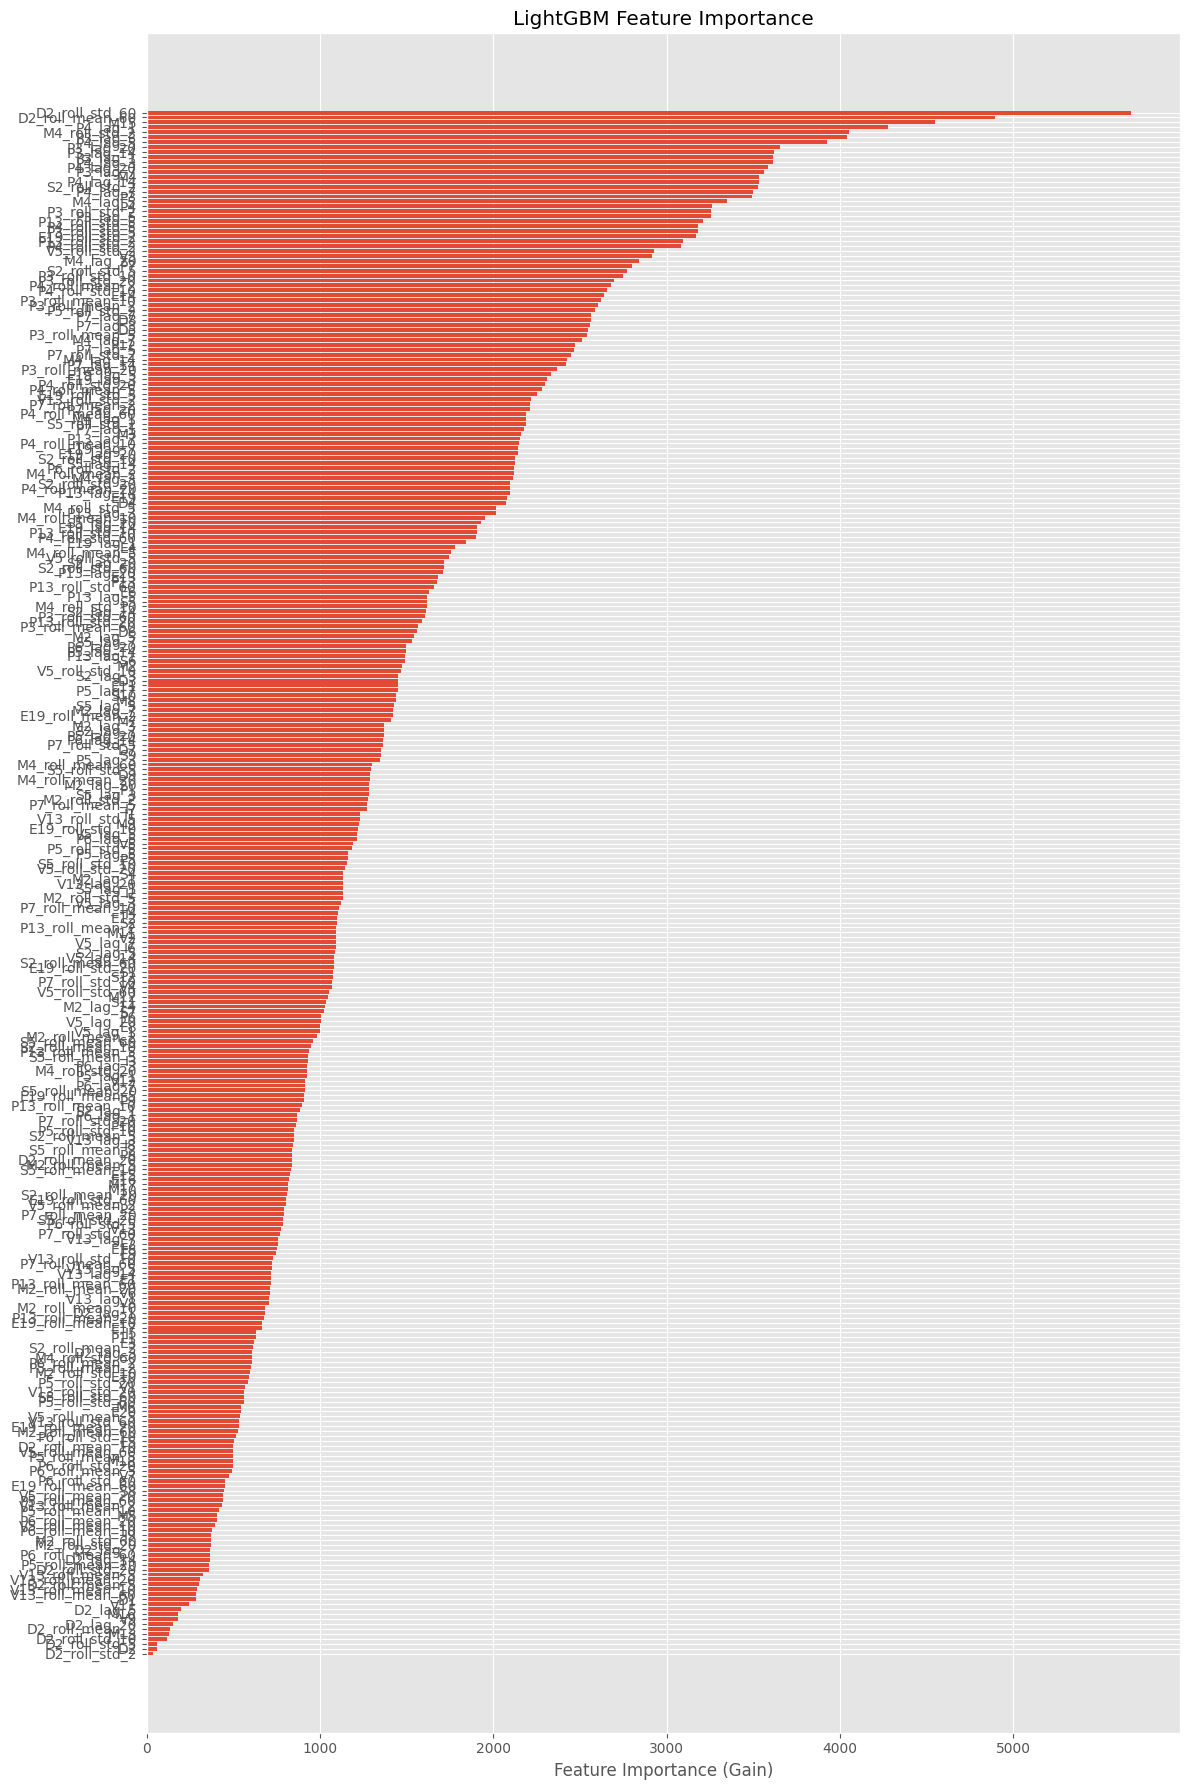

In [11]:
# === Feature Importance Plot ===

importance = final_model.feature_importances_
indices = np.argsort(importance)[::-1]
sorted_features = np.array(FEATURES)[indices]
sorted_importance = importance[indices]

plt.figure(figsize=(12, 18))
plt.barh(sorted_features, sorted_importance)
plt.xlabel("Feature Importance (Gain)")
plt.title("LightGBM Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
print("Loading artifacts for inference...")
try:
    # Load LightGBM model and features
    model = joblib.load(MODEL_PATH)
    MODEL_FEATURES = joblib.load(FEATURES_PATH)
except Exception as e:
    raise RuntimeError(
        f"Could not load model/features. Ensure training was successful. Error: {e}"
    )

print("Initializing prediction history...")
history_df = pd.read_csv(TRAIN_PATH)

cols_to_drop_hist = [
    col for col in COLS_TO_DROP 
    if col in history_df.columns and col != TARGET
]
history_df.drop(columns=cols_to_drop_hist, inplace=True)

if 'date_id' not in history_df.columns:
    history_df['date_id'] = history_df.index

print("Setup complete. Ready for prediction.")

def convert_ret_to_signal(ret_arr: np.ndarray) -> np.ndarray:
    """
    Convert an array of returns to discrete trading signals 0, 1, 2
    """
    q75 = max(0, np.quantile(ret_arr, 0.75))

    signal = np.zeros_like(ret_arr, dtype=int)

    signal[(ret_arr > 0) & (ret_arr <= q75)] = 1

    signal[ret_arr > q75] = 2

    return signal
    
def predict(test_df_pl: pl.DataFrame) -> float:
    global history_df

    # Convert to pandas
    test_df_pd = test_df_pl.to_pandas()

    # Assign next date_id
    if 'date_id' not in test_df_pd.columns:
        last_date_id = history_df['date_id'].max() if not history_df.empty else -1
        test_df_pd['date_id'] = last_date_id + 1

    # Update history
    history_df = pd.concat([history_df, test_df_pd], ignore_index=True)

    # Slice window for feature creation
    slice_size = max(ROLLING_WINDOWS) + max(LAG_PERIODS) + 5
    historical_slice = history_df.tail(slice_size)

    processed_slice = create_features(historical_slice)

    # Select only model feature columns (LightGBM)
    current_features = processed_slice.tail(1)[MODEL_FEATURES]

    # Predict
    prediction = model.predict(current_features)[0]

    signals = convert_ret_to_signal(prediction)
    # # Allocation calculation
    # allocation = np.clip(1 + BEST_C * prediction, 0, 2)

    gc.collect()

    return float(signals)


# Inference server setup
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    print("Serving predictions for the competition...")
    inference_server.serve()
else:
    print("Running local gateway for testing...")
    inference_server.run_local_gateway((LOCAL_GATEWAY_PATH,))

print("Submission script finished.")

Loading artifacts for inference...
Initializing prediction history...
Setup complete. Ready for prediction.
Running local gateway for testing...
Submission script finished.
